In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [ ]:
import os
from google.colab import files
import urllib
folder_path = '/content/drive/My Drive/dataset_split'



In [ ]:
# Creating a path for the dataset
train_dir = os.path.join('/content/drive/My Drive/dataset_split', 'train')
val_dir = os.path.join('/content/drive/My Drive/dataset_split', 'val')
test_dir = os.path.join('/content/drive/My Drive/dataset_split', 'test')
# Check the directories
print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)


Train directory: /content/drive/My Drive/dataset_split/train
Validation directory: /content/drive/My Drive/dataset_split/val
Test directory: /content/drive/My Drive/dataset_split/test


In [ ]:
print("Train directory contents:", os.listdir(train_dir))
print("Validation directory contents:", os.listdir(val_dir))
print("Test directory contents:", os.listdir(test_dir))

Train directory contents: ['other', 'organic_waste', 'metal', 'glass', 'paper_and_cardboard', 'plastic', 'textiles']
Validation directory contents: ['textiles', 'metal', 'other', 'glass', 'organic_waste', 'paper_and_cardboard', 'plastic']
Test directory contents: ['other', 'metal', 'paper_and_cardboard', 'glass', 'plastic', 'textiles', 'organic_waste']


In [ ]:
#create batch size
batch_size = 32
# Set image size
img_size = (160, 160)

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir, shuffle=True, batch_size=batch_size, image_size=img_size, label_mode='categorical')
validation_dataset = tf.keras.utils.image_dataset_from_directory(val_dir, shuffle=True, batch_size=batch_size, image_size=img_size, label_mode='categorical')
test_dataset = tf.keras.utils.image_dataset_from_directory(test_dir, shuffle=True, batch_size=batch_size, image_size=img_size, label_mode='categorical')

Found 1225 files belonging to 7 classes.
Found 259 files belonging to 7 classes.
Found 266 files belonging to 7 classes.


In [ ]:
class_names = train_dataset.class_names

In [ ]:
tf.data.AUTOTUNE

-1

In [ ]:
autotune = tf.data.AUTOTUNE

In [ ]:
train_dataset = train_dataset.prefetch(buffer_size=autotune)
validation_dataset = validation_dataset.prefetch(buffer_size=autotune)
test_dataset = test_dataset.prefetch(buffer_size=autotune)

In [ ]:
img_shape = img_size + (3,)

In [ ]:
img_size

(160, 160)

In [ ]:
img_shape

(160, 160, 3)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(input_shape=img_shape,
                                               include_top=False,
                                               weights='imagenet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
inputs = tf.keras.Input(shape=img_shape)
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)

In [ ]:
from tensorflow.keras.layers import Dropout

#if len(x.shape) == 2:
    #x = tf.keras.layers.Reshape((-1, 1, x.shape[-1]))(x)

global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
x = global_average_layer(x)
num_classes = 7
x = Dropout(0.5)(x)
prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 7)                   │           8,967 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
base_learning_rate = 0.01
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=batch_size,
    decay_rate=0.8)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(filepath='best_model.keras', monitor='val_loss', save_best_only=True)

In [ ]:
initial_epochs = 40

In [ ]:
import json

history = model.fit(
    train_dataset,
    epochs=initial_epochs,
    validation_data=validation_dataset,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1  )

with open('training_history.json', 'w') as file:
    json.dump(history.history, file)

Epoch 1/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 516s 13s/step - accuracy: 0.6338 - loss: 1.1856 - val_accuracy: 0.9073 - val_loss: 0.3056
Epoch 2/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 74s 600ms/step - accuracy: 0.9166 - loss: 0.2954 - val_accuracy: 0.9035 - val_loss: 0.3807
Epoch 3/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 615ms/step - accuracy: 0.9426 - loss: 0.1797 - val_accuracy: 0.9073 - val_loss: 0.3420
Epoch 4/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 24s 621ms/step - accuracy: 0.9543 - loss: 0.1413 - val_accuracy: 0.9151 - val_loss: 0.2612
Epoch 5/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 40s 588ms/step - accuracy: 0.9586 - loss: 0.1129 - val_accuracy: 0.9189 - val_loss: 0.2749
Epoch 6/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 594ms/step - accuracy: 0.9635 - loss: 0.1120 - val_accuracy: 0.9151 - val_loss: 0.2834
Epoch 7/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 582ms/step - accuracy: 0.9684 - loss: 0.0863 - val_accuracy: 0.9035 - val_loss: 0.2918
Epoch 8/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 570ms/step - accuracy: 0.9769 - loss: 0.0538 - val_accur

In [ ]:
base_model.trainable = True

In [ ]:
len(base_model.layers)

154

In [ ]:
for layer in base_model.layers[:100]:
    layer.trainable = False

In [ ]:
base_learning_rate
fine_tune_learning_rate = base_learning_rate / 10

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')])

In [ ]:
fine_tune_early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
fine_tune_model_checkpoint = ModelCheckpoint(filepath='fine_tuned_model.keras', monitor='val_loss', save_best_only=True)

In [ ]:
fine_tune_epochs = 40
total_epochs = initial_epochs + fine_tune_epochs

In [ ]:
history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=validation_dataset,
    callbacks=[fine_tune_early_stopping, fine_tune_model_checkpoint],
    verbose=1
)

with open('fine_tuning_history.json', 'w') as file:
    json.dump(history_fine.history, file)

Epoch 9/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 49s 939ms/step - accuracy: 0.7716 - loss: 0.8580 - val_accuracy: 0.6718 - val_loss: 2.3098
Epoch 10/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 38s 861ms/step - accuracy: 0.9157 - loss: 0.2562 - val_accuracy: 0.6100 - val_loss: 4.5164
Epoch 11/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 43s 910ms/step - accuracy: 0.9630 - loss: 0.1229 - val_accuracy: 0.7568 - val_loss: 2.5191
Epoch 12/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 33s 850ms/step - accuracy: 0.9574 - loss: 0.1687 - val_accuracy: 0.6255 - val_loss: 4.8834
Epoch 13/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 34s 867ms/step - accuracy: 0.9498 - loss: 0.1888 - val_accuracy: 0.3514 - val_loss: 17.4823
Epoch 14/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 867ms/step - accuracy: 0.9569 - loss: 0.1327 - val_accuracy: 0.5135 - val_loss: 15.9315


In [ ]:
# Using the best model
model = tf.keras.models.load_model('fine_tuned_model.keras')

In [ ]:
# Evaluate the fine-tuned model on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

9/9 ━━━━━━━━━━━━━━━━━━━━ 96s 10s/step - accuracy: 0.6564 - loss: 2.4019


In [ ]:
# Load training history
with open('training_history.json', 'r') as file:
    training_history = json.load(file)

# Load fine-tuning history
with open('fine_tuning_history.json', 'r') as file:
    fine_tuning_history = json.load(file)

In [ ]:
# Combine training and fine-tuning metrics
acc = training_history['accuracy'] + fine_tuning_history['accuracy']
val_acc = training_history['val_accuracy'] + fine_tuning_history['val_accuracy']

loss = training_history['loss'] + fine_tuning_history['loss']
val_loss = training_history['val_loss'] + fine_tuning_history['val_loss']

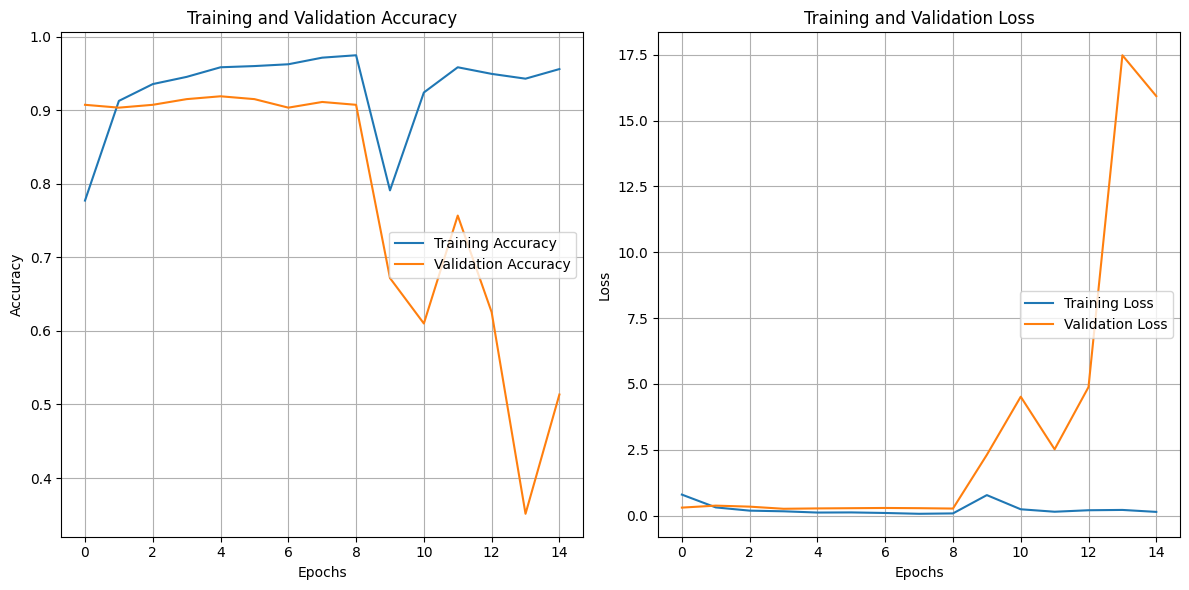

In [ ]:
# Plot accuracy and loss on the same grid
plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right', bbox_to_anchor=(1, 0.5))
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right', bbox_to_anchor=(1, 0.5))
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
y_true = []
y_pred = []

for X, labels in test_dataset:
    preds = model.predict(X)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)  # Only if one-hot

    y_true.extend(true_classes)
    y_pred.extend(pred_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 7)                   │           8,967 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,007,767 (22.92 MB)

 Trainable params: 1,870,407 (7.14 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 3,740,816 (14.27 MB)

In [ ]:
class_names

['glass',
 'metal',
 'organic_waste',
 'other',
 'paper_and_cardboard',
 'plastic',
 'textiles']

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

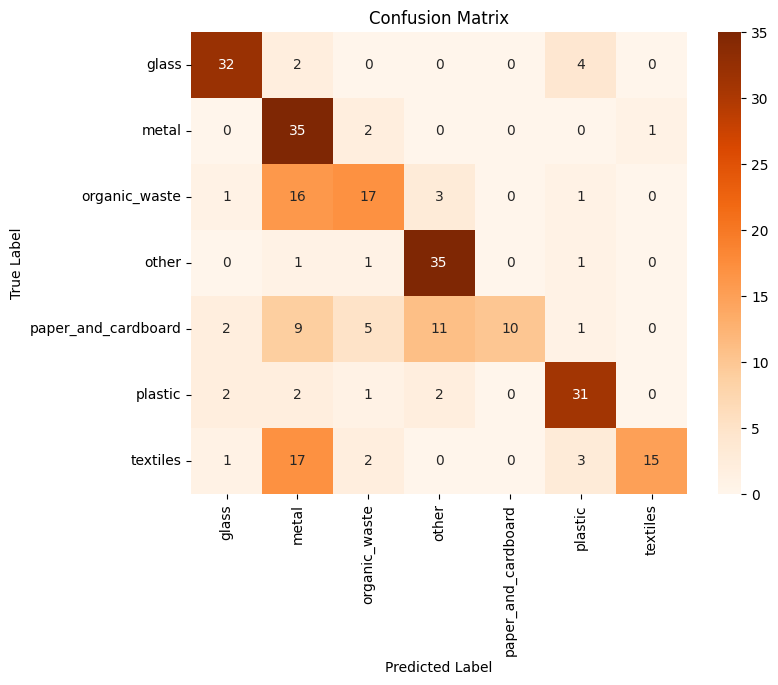

In [ ]:
# Compute confusion a
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
ground_truth

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                     precision    recall  f1-score   support

              glass       0.84      0.84      0.84        38
              metal       0.43      0.92      0.58        38
      organic_waste       0.61      0.45      0.52        38
              other       0.69      0.92      0.79        38
paper_and_cardboard       1.00      0.26      0.42        38
            plastic       0.76      0.82      0.78        38
           textiles       0.94      0.39      0.56        38

           accuracy                           0.66       266
          macro avg       0.75      0.66      0.64       266
       weighted avg       0.75      0.66      0.64       266



In [ ]:
image_batch, label_batch = test_dataset.as_numpy_iterator().next()

In [ ]:
y_true = []
y_pred = []

for X, labels in test_dataset:
    preds = model.predict(X)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)  # Only if one-hot

    y_true.extend(true_classes)
    y_pred.extend(pred_classes)

IndexError: index 10 is out of bounds for axis 0 with size 10

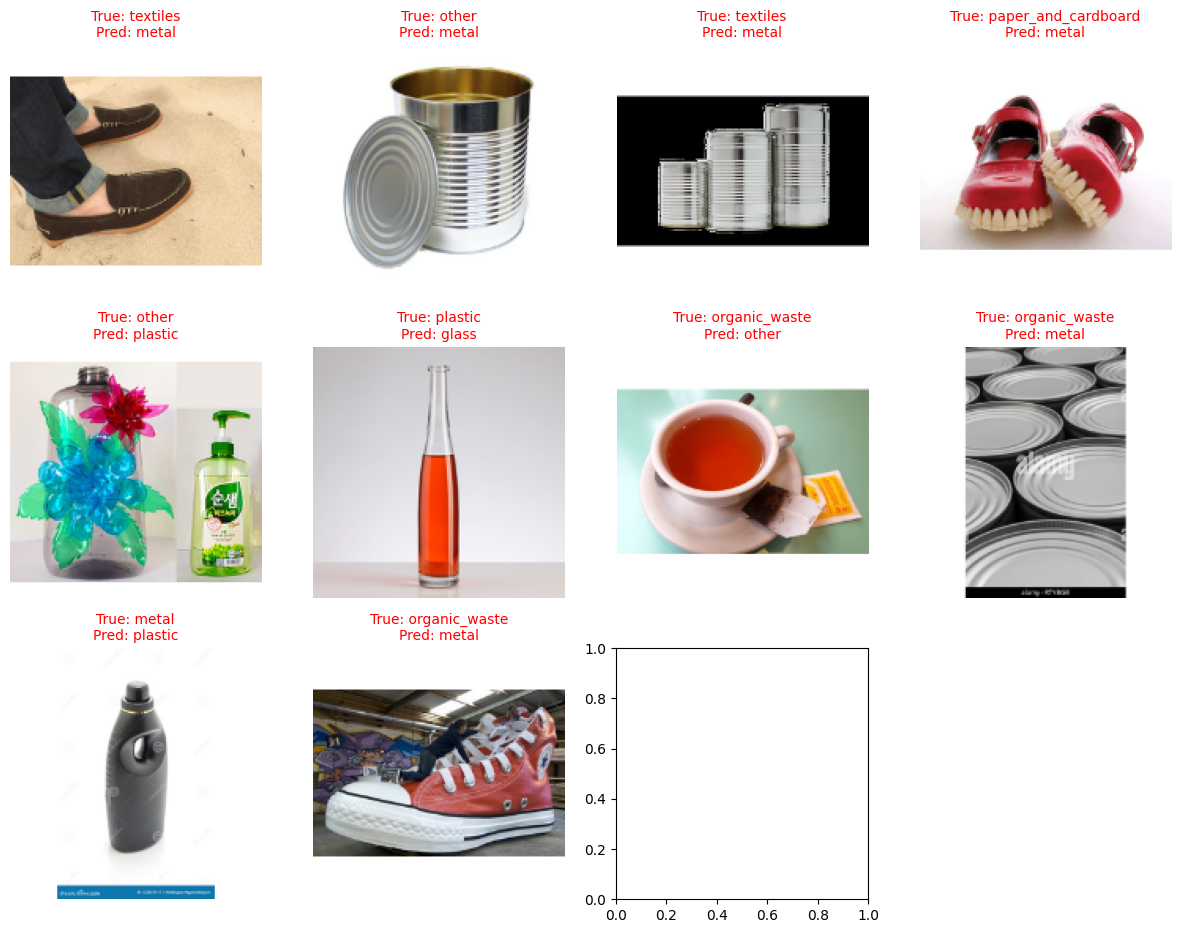

In [ ]:
for image_batch, label_batch in test_dataset:
    # Predict on batch
    predictions = model.predict_on_batch(image_batch)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)


    y_true.extend(true_classes)
    y_pred.extend(pred_classes)

# Optional: Evaluate or visualize some results
# Let's visualize the first 16 predictions
plt.figure(figsize=(15, 15))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    #image = image_batch[i] # Last batch
    true_label = true_classes[i]
    pred_label = pred_classes[i]

    title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    color = 'green' if true_label == pred_label else 'red'
    image = image_batch[i]
    if hasattr(image, 'numpy'):
      image = image.numpy()
    plt.imshow(image.astype("uint8"))
    plt.title(title, color=color, fontsize=10)
    plt.axis("off")

plt.suptitle("Predictions on Test Data", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()